In [1]:
# Cell 1 — Imports
import sys
sys.path.append("..")

import numpy as np
import pandas as pd
import pickle
import time
import warnings
warnings.filterwarnings("ignore")

import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import balanced_accuracy_score
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from shared.config import *
from shared.metrics import ids_evaluate, tune_threshold
from shared.plots import plot_metrics_bar, plot_frontier

print("Imports OK")

Config loaded successfully
Imports OK


In [2]:
# Cell 1b — Install dependencies
import sys
!{sys.executable} -m pip install --upgrade imbalanced-learn scikit-learn optuna pyswarms --quiet

In [2]:
# Cell 2 — Load splits from notebook 01
with open("models/splits.pkl", "rb") as f:
    splits = pickle.load(f)

X_train = splits["X_train"]
X_val   = splits["X_val"]
X_test  = splits["X_test"]
y_train = splits["y_train"]
y_val   = splits["y_val"]
y_test  = splits["y_test"]

print(f"Train : {X_train.shape}")
print(f"Val   : {X_val.shape}")
print(f"Test  : {X_test.shape}")

Train : (11363049, 34)
Val   : (2434939, 34)
Test  : (2434940, 34)


In [3]:
# Cell 2b — Load previous ML results from notebook 02
# We use the all_results dict we built in 02 to compare against
import os

if os.path.exists("models/ml/all_results.pkl"):
    with open("models/ml/all_results.pkl", "rb") as f:
        all_results = pickle.load(f)
    print(f"Loaded {len(all_results)} baseline ML results")
else:
    # Manually populate from 02 notebook outputs
    all_results = {
        "Decision Tree": {"Model": "Decision Tree", "Balanced Acc": 0.9748, "F1 Macro": 0.9784,
                          "MCC": 0.9569, "Attack Recall": 0.9549, "Benign Recall": 0.9947,
                          "Attack Precision": 0.9734, "Benign Precision": 0.9908,
                          "FAR": 0.0053, "FNR": 0.0451, "ROC-AUC": 0.9878, "PR-AUC": 0.9741,
                          "Train Time (s)": 162.47, "Threshold": 0.1485},
        "Random Forest": {"Model": "Random Forest", "Balanced Acc": 0.9718, "F1 Macro": 0.9822,
                          "MCC": 0.9649, "Attack Recall": 0.9439, "Benign Recall": 0.9996,
                          "Attack Precision": 0.9980, "Benign Precision": 0.9887,
                          "FAR": 0.0004, "FNR": 0.0561, "ROC-AUC": 0.9915, "PR-AUC": 0.9826,
                          "Train Time (s)": 879.22, "Threshold": 0.5},
        "KNN":           {"Model": "KNN", "Balanced Acc": 0.9724, "F1 Macro": 0.9767,
                          "MCC": 0.9535, "Attack Recall": 0.9503, "Benign Recall": 0.9945,
                          "Attack Precision": 0.9724, "Benign Precision": 0.9899,
                          "FAR": 0.0055, "FNR": 0.0497, "ROC-AUC": 0.9776, "PR-AUC": 0.9620,
                          "Train Time (s)": 0.0, "Threshold": 0.4},
        "XGBoost":       {"Model": "XGBoost", "Balanced Acc": 0.9717, "F1 Macro": 0.9821,
                          "MCC": 0.9648, "Attack Recall": 0.9437, "Benign Recall": 0.9997,
                          "Attack Precision": 0.9982, "Benign Precision": 0.9886,
                          "FAR": 0.0003, "FNR": 0.0563, "ROC-AUC": 0.9919, "PR-AUC": 0.9832,
                          "Train Time (s)": 76.85, "Threshold": 0.5},
        "LightGBM":      {"Model": "LightGBM", "Balanced Acc": 0.9712, "F1 Macro": 0.9820,
                          "MCC": 0.9645, "Attack Recall": 0.9426, "Benign Recall": 0.9998,
                          "Attack Precision": 0.9988, "Benign Precision": 0.9884,
                          "FAR": 0.0002, "FNR": 0.0574, "ROC-AUC": 0.9904, "PR-AUC": 0.9811,
                          "Train Time (s)": 42.43, "Threshold": 0.5},
    }
    print(f"Populated {len(all_results)} baseline results manually from notebook 02")

# Baseline XGBoost for comparison throughout this notebook
baseline_xgb = all_results["XGBoost"]
print(f"\nBaseline XGBoost — Balanced Acc: {baseline_xgb['Balanced Acc']}  "
      f"Attack Recall: {baseline_xgb['Attack Recall']}")

Loaded 2 baseline ML results

Baseline XGBoost — Balanced Acc: 0.9717  Attack Recall: 0.9437


In [5]:
# Cell 3 — Optuna Bayesian HPO on XGBoost
def objective(trial):
    params = {
        "n_estimators"    : trial.suggest_int("n_estimators", 200, 600),
        "max_depth"       : trial.suggest_int("max_depth", 4, 10),
        "learning_rate"   : trial.suggest_float("learning_rate", 0.01, 0.1, log=True),
        "subsample"       : trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.6, 1.0),
        "tree_method"     : "hist",
        "device"          : "cpu",
        "eval_metric"     : "logloss",
        "random_state"    : RANDOM_STATE
    }
    clf = XGBClassifier(**params)
    clf.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=30,
            verbose=False)

    # Use direct proba to avoid expensive tune_threshold on val set per trial
    proba  = clf.predict_proba(X_val)[:, 1]
    y_pred = (proba >= 0.5).astype(int)
    return balanced_accuracy_score(y_val, y_pred)

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"Best params      : {study.best_params}")
print(f"Best Balanced Acc: {study.best_value:.4f}")

  0%|          | 0/30 [00:00<?, ?it/s]

Best params      : {'n_estimators': 504, 'max_depth': 10, 'learning_rate': 0.08149098517000931, 'subsample': 0.8278848607910456, 'colsample_bytree': 0.7924539410862861}
Best Balanced Acc: 0.9718


In [6]:
# Cell 4 — Train best XGBoost with Optuna params
print("Training XGBoost+Optuna with best params...")
start = time.time()

best_xgb = XGBClassifier(
    **study.best_params,
    tree_method="hist",
    device="cpu",
    random_state=RANDOM_STATE
)
best_xgb.fit(X_train, y_train,
             eval_set=[(X_val, y_val)],
             early_stopping_rounds=50,
             verbose=False)

train_time = time.time() - start
print(f"Done in {train_time:.1f}s")

proba_optuna  = best_xgb.predict_proba(X_test)[:, 1]
y_pred_optuna = (proba_optuna >= 0.5).astype(int)
th_optuna     = 0.5

optuna_m = ids_evaluate("XGBoost+Optuna", y_test.values,
                         proba_optuna, y_pred_optuna, th_optuna)
optuna_m["Train Time (s)"] = round(train_time, 2)
optuna_m["Threshold"]      = th_optuna

print("\nXGBoost+Optuna metrics:")
for k, v in optuna_m.items():
    print(f"  {k}: {v}")

with open("models/ml/best_xgb.pkl", "wb") as f:
    pickle.dump(best_xgb, f)
with open("models/ml/optuna_study.pkl", "wb") as f:
    pickle.dump(study, f)
print("\nModels saved.")

Training XGBoost+Optuna with best params...
Done in 243.2s

XGBoost+Optuna metrics:
  Model: XGBoost+Optuna
  Balanced Acc: 0.9719
  F1 Macro: 0.9821
  MCC: 0.9648
  Attack Recall: 0.9442
  Benign Recall: 0.9995
  Attack Precision: 0.9976
  Benign Precision: 0.9887
  FAR: 0.0005
  FNR: 0.0558
  ROC-AUC: 0.9927
  PR-AUC: 0.9842
  Train Time (s): 243.24
  Threshold: 0.5

Models saved.


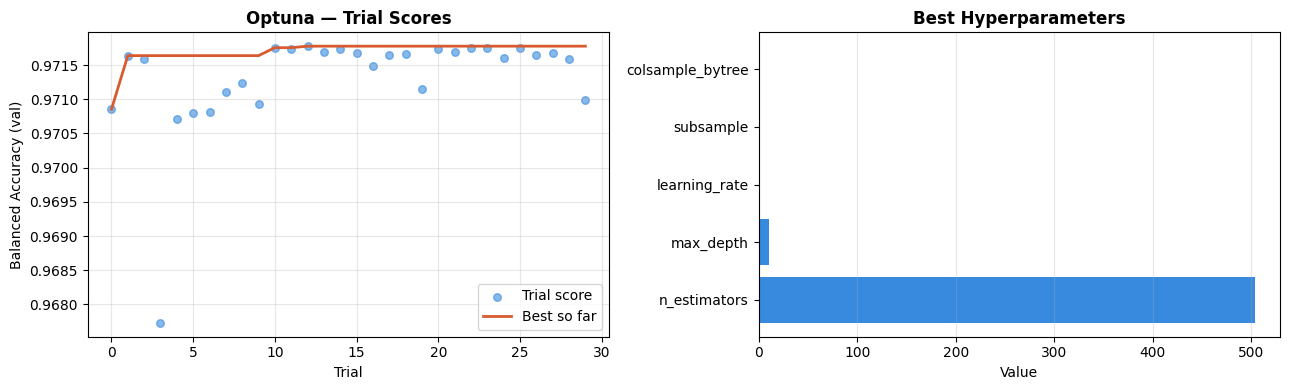

In [7]:
# Cell 5 — Optuna convergence graphs
trial_nums  = [t.number for t in study.trials]
trial_vals  = [t.value  for t in study.trials]
best_so_far = [max(trial_vals[:i+1]) for i in range(len(trial_vals))]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].scatter(trial_nums, trial_vals, s=30, alpha=0.6,
                color="#378ADD", label="Trial score")
axes[0].plot(trial_nums, best_so_far,
             color="#D85A30", linewidth=2, label="Best so far")
axes[0].set_xlabel("Trial")
axes[0].set_ylabel("Balanced Accuracy (val)")
axes[0].set_title("Optuna — Trial Scores", fontweight="bold")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

param_names = list(study.best_params.keys())
param_vals  = [study.best_params[p] for p in param_names]
axes[1].barh(param_names, param_vals, color="#378ADD")
axes[1].set_title("Best Hyperparameters", fontweight="bold")
axes[1].set_xlabel("Value")
axes[1].grid(True, axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("outputs/graphs/03_optuna_convergence.png", dpi=150)
plt.show()

In [8]:
# Cell 6 — Feature Importance selection (top PSO_TOP_N features)
print("Running Feature Importance selection...")
importances   = best_xgb.feature_importances_
feature_names = X_train.columns.tolist()
sorted_idx    = np.argsort(importances)[::-1]
top_features  = [feature_names[i] for i in sorted_idx[:PSO_TOP_N]]

print(f"Top {PSO_TOP_N} features selected from {len(feature_names)} total")

X_train_fi = X_train[top_features]
X_val_fi   = X_val[top_features]
X_test_fi  = X_test[top_features]

start = time.time()
xgb_fi = XGBClassifier(**study.best_params,
                        tree_method="hist",
                        device="cpu",
                        random_state=RANDOM_STATE)
xgb_fi.fit(X_train_fi, y_train,
           eval_set=[(X_val_fi, y_val)],
           early_stopping_rounds=50, verbose=False)
train_time = time.time() - start

proba_fi  = xgb_fi.predict_proba(X_test_fi)[:, 1]
y_pred_fi = (proba_fi >= 0.5).astype(int)

fi_m = ids_evaluate("Feat. Importance", y_test.values,
                     proba_fi, y_pred_fi, 0.5)
fi_m["Train Time (s)"] = round(train_time, 2)
fi_m["Threshold"]      = 0.5

print(f"Done in {train_time:.1f}s")
for k, v in fi_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_fi.pkl", "wb") as f:
    pickle.dump(xgb_fi, f)

Running Feature Importance selection...
Top 30 features selected from 34 total
Done in 351.0s
  Model: Feat. Importance
  Balanced Acc: 0.9719
  F1 Macro: 0.9822
  MCC: 0.9649
  Attack Recall: 0.9443
  Benign Recall: 0.9995
  Attack Precision: 0.9976
  Benign Precision: 0.9888
  FAR: 0.0005
  FNR: 0.0557
  ROC-AUC: 0.9927
  PR-AUC: 0.9842
  Train Time (s): 351.04
  Threshold: 0.5


In [9]:
# Cell 7 — Univariate SelectKBest
print("Running Univariate SelectKBest...")
selector = SelectKBest(score_func=f_classif, k=PSO_TOP_N)
selector.fit(X_train, y_train)

X_train_uni = selector.transform(X_train)
X_val_uni   = selector.transform(X_val)
X_test_uni  = selector.transform(X_test)

print(f"Selected {PSO_TOP_N} features via f_classif")

start = time.time()
xgb_uni = XGBClassifier(**study.best_params,
                         tree_method="hist",
                         device="cpu",
                         random_state=RANDOM_STATE)
xgb_uni.fit(X_train_uni, y_train,
            eval_set=[(X_val_uni, y_val)],
            early_stopping_rounds=50, verbose=False)
train_time = time.time() - start

proba_uni  = xgb_uni.predict_proba(X_test_uni)[:, 1]
y_pred_uni = (proba_uni >= 0.5).astype(int)

uni_m = ids_evaluate("Univariate (KB)", y_test.values,
                      proba_uni, y_pred_uni, 0.5)
uni_m["Train Time (s)"] = round(train_time, 2)
uni_m["Threshold"]      = 0.5

print(f"Done in {train_time:.1f}s")
for k, v in uni_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_uni.pkl", "wb") as f:
    pickle.dump(xgb_uni, f)
with open("models/ml/selector_uni.pkl", "wb") as f:
    pickle.dump(selector, f)

Running Univariate SelectKBest...
Selected 30 features via f_classif
Done in 337.9s
  Model: Univariate (KB)
  Balanced Acc: 0.9719
  F1 Macro: 0.9822
  MCC: 0.9648
  Attack Recall: 0.9443
  Benign Recall: 0.9995
  Attack Precision: 0.9976
  Benign Precision: 0.9888
  FAR: 0.0005
  FNR: 0.0557
  ROC-AUC: 0.9928
  PR-AUC: 0.9843
  Train Time (s): 337.95
  Threshold: 0.5


In [10]:
# Cell 8 — PCA dimensionality reduction
print("Running PCA...")
scaler_pca   = StandardScaler()
X_tr_pca_raw = scaler_pca.fit_transform(X_train)
X_va_pca_raw = scaler_pca.transform(X_val)
X_te_pca_raw = scaler_pca.transform(X_test)

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_tr_pca_raw)
X_val_pca   = pca.transform(X_va_pca_raw)
X_test_pca  = pca.transform(X_te_pca_raw)

print(f"Original : {X_train.shape[1]} features")
print(f"PCA      : {pca.n_components_} components (95% variance)")
print(f"Variance : {pca.explained_variance_ratio_.sum():.4f}")

start = time.time()
xgb_pca = XGBClassifier(**study.best_params,
                         tree_method="hist",
                         device="cpu",
                         random_state=RANDOM_STATE)
xgb_pca.fit(X_train_pca, y_train,
            eval_set=[(X_val_pca, y_val)],
            early_stopping_rounds=50, verbose=False)
train_time = time.time() - start

proba_pca  = xgb_pca.predict_proba(X_test_pca)[:, 1]
y_pred_pca = (proba_pca >= 0.5).astype(int)

pca_m = ids_evaluate("PCA", y_test.values,
                      proba_pca, y_pred_pca, 0.5)
pca_m["Train Time (s)"] = round(train_time, 2)
pca_m["Threshold"]      = 0.5

print(f"Done in {train_time:.1f}s")
for k, v in pca_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_pca.pkl", "wb") as f:
    pickle.dump(xgb_pca, f)
with open("models/ml/pca_scaler.pkl", "wb") as f:
    pickle.dump(scaler_pca, f)
with open("models/ml/pca.pkl", "wb") as f:
    pickle.dump(pca, f)

Running PCA...
Original : 34 features
PCA      : 11 components (95% variance)
Variance : 0.9552
Done in 294.2s
  Model: PCA
  Balanced Acc: 0.9715
  F1 Macro: 0.9819
  MCC: 0.9643
  Attack Recall: 0.9436
  Benign Recall: 0.9995
  Attack Precision: 0.9974
  Benign Precision: 0.9886
  FAR: 0.0005
  FNR: 0.0564
  ROC-AUC: 0.99
  PR-AUC: 0.9806
  Train Time (s): 294.19
  Threshold: 0.5


In [11]:
# Cell 9 — PSO Feature Selection
import pyswarms as ps

print(f"Running PSO feature selection on {SAMPLE_PSO} samples...")

# Stratified subsample for PSO (fast evaluation per particle)
from sklearn.model_selection import train_test_split as tts
_, X_tr_pso_df, _, y_tr_pso = tts(
    X_train, y_train.values,
    test_size=SAMPLE_PSO / len(X_train),
    stratify=y_train.values,
    random_state=RANDOM_STATE
)
X_tr_pso = X_tr_pso_df.values
X_va_pso = X_val.values
y_va_pso = y_val.values
n_feat   = X_tr_pso.shape[1]

def pso_objective(particles):
    costs = []
    for particle in particles:
        mask = particle > 0.5
        if mask.sum() == 0:
            costs.append(1.0)
            continue
        clf = XGBClassifier(
            n_estimators=100, max_depth=5,
            tree_method="hist", device="cpu",
            random_state=RANDOM_STATE, verbosity=0
        )
        clf.fit(X_tr_pso[:, mask], y_tr_pso)
        proba_v = clf.predict_proba(X_va_pso[:, mask])[:, 1]
        y_pred  = (proba_v >= 0.5).astype(int)
        costs.append(1 - balanced_accuracy_score(y_va_pso, y_pred))
    return np.array(costs)

options   = {"c1": 0.5, "c2": 0.3, "w": 0.9}
optimizer = ps.single.GlobalBestPSO(
    n_particles=PSO_PARTICLES,
    dimensions=n_feat,
    options=options,
    bounds=(np.zeros(n_feat), np.ones(n_feat))
)
best_cost, best_pos = optimizer.optimize(pso_objective, iters=PSO_ITERS)

pso_mask     = best_pos > 0.5
pso_features = [f for f, s in zip(X_train.columns, pso_mask) if s]
print(f"PSO selected {pso_mask.sum()} / {n_feat} features")
print(f"Selected: {pso_features}")

X_train_pso = X_train[pso_features]
X_val_pso   = X_val[pso_features]
X_test_pso  = X_test[pso_features]

start = time.time()
xgb_pso = XGBClassifier(**study.best_params,
                         tree_method="hist",
                         device="cpu",
                         random_state=RANDOM_STATE)
xgb_pso.fit(X_train_pso, y_train,
            eval_set=[(X_val_pso, y_val)],
            early_stopping_rounds=50, verbose=False)
train_time = time.time() - start

proba_pso  = xgb_pso.predict_proba(X_test_pso)[:, 1]
y_pred_pso = (proba_pso >= 0.5).astype(int)

pso_m = ids_evaluate("PSO", y_test.values,
                      proba_pso, y_pred_pso, 0.5)
pso_m["Train Time (s)"] = round(train_time, 2)
pso_m["Threshold"]      = 0.5

print(f"Done in {train_time:.1f}s")
for k, v in pso_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_pso.pkl", "wb") as f:
    pickle.dump(xgb_pso, f)
with open("models/ml/pso_features.pkl", "wb") as f:
    pickle.dump(pso_features, f)

Running PSO feature selection on 50000 samples...


2026-03-27 23:00:12,831 - pyswarms.single.global_best - INFO - Optimize for 20 iters with {'c1': 0.5, 'c2': 0.3, 'w': 0.9}
pyswarms.single.global_best: 100%|██████████|20/20, best_cost=0.0287
2026-03-27 23:03:14,163 - pyswarms.single.global_best - INFO - Optimization finished | best cost: 0.028682443205985786, best pos: [0.90819927 0.09158565 0.38132258 0.1988035  0.60338013 0.90382531
 0.78385656 0.74201459 0.35886356 0.96690555 0.78710593 0.65326821
 0.0475224  0.66443396 0.65927746 0.42966746 0.07407075 0.97279571
 0.90709052 0.12343233 0.25742768 0.40900282 0.61309906 0.77414367
 0.38233745 0.72969472 0.12729581 0.82231448 0.15505886 0.58021336
 0.09731668 0.78795889 0.53518688 0.40431444]


PSO selected 19 / 34 features
Selected: ['Dst Port', 'TotLen Fwd Pkts', 'Fwd Pkt Len Max', 'Fwd Pkt Len Mean', 'Bwd Pkt Len Mean', 'Flow Pkts/s', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Std', 'Bwd IAT Tot', 'Bwd IAT Max', 'Bwd IAT Min', 'Pkt Len Var', 'RST Flag Cnt', 'ACK Flag Cnt', 'Down/Up Ratio', 'Init Fwd Win Byts', 'Fwd Act Data Pkts', 'Fwd Seg Size Min']
Done in 300.1s
  Model: PSO
  Balanced Acc: 0.9719
  F1 Macro: 0.9821
  MCC: 0.9648
  Attack Recall: 0.9443
  Benign Recall: 0.9995
  Attack Precision: 0.9975
  Benign Precision: 0.9888
  FAR: 0.0005
  FNR: 0.0557
  ROC-AUC: 0.9926
  PR-AUC: 0.984
  Train Time (s): 300.13
  Threshold: 0.5


In [12]:
# Cell 10 — SMOTE resampling
print(f"Running SMOTE on {SAMPLE_SMOTE} samples...")

# Stratified subsample before SMOTE (SMOTE is memory intensive on 11M rows)
from sklearn.model_selection import train_test_split as tts
_, X_sm_df, _, y_sm_raw = tts(
    X_train, y_train.values,
    test_size=SAMPLE_SMOTE / len(X_train),
    stratify=y_train.values,
    random_state=RANDOM_STATE
)
X_sm_raw = X_sm_df.values

print(f"Before SMOTE: {np.bincount(y_sm_raw)}")
smote      = SMOTE(random_state=RANDOM_STATE)
X_sm, y_sm = smote.fit_resample(X_sm_raw, y_sm_raw)
print(f"After  SMOTE: {np.bincount(y_sm)}")

start = time.time()
xgb_smote = XGBClassifier(**study.best_params,
                           tree_method="hist",
                           device="cpu",
                           random_state=RANDOM_STATE)
xgb_smote.fit(X_sm, y_sm)
train_time = time.time() - start

proba_smote  = xgb_smote.predict_proba(X_test)[:, 1]
y_pred_smote = (proba_smote >= 0.5).astype(int)

smote_m = ids_evaluate("SMOTE", y_test.values,
                        proba_smote, y_pred_smote, 0.5)
smote_m["Train Time (s)"] = round(train_time, 2)
smote_m["Threshold"]      = 0.5

print(f"Done in {train_time:.1f}s")
for k, v in smote_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_smote.pkl", "wb") as f:
    pickle.dump(xgb_smote, f)

Running SMOTE on 150000 samples...
Before SMOTE: [124605  25395]
After  SMOTE: [124605 124605]
Done in 7.3s
  Model: SMOTE
  Balanced Acc: 0.9733
  F1 Macro: 0.9758
  MCC: 0.9517
  Attack Recall: 0.9533
  Benign Recall: 0.9932
  Attack Precision: 0.9663
  Benign Precision: 0.9905
  FAR: 0.0068
  FNR: 0.0467
  ROC-AUC: 0.9875
  PR-AUC: 0.9773
  Train Time (s): 7.31
  Threshold: 0.5


In [13]:
# Cell 11 — scale_pos_weight (class imbalance correction)
n_benign = int((y_train == 0).sum())
n_attack = int((y_train == 1).sum())
spw      = n_benign / n_attack
print(f"Benign samples   : {n_benign:,}")
print(f"Attack samples   : {n_attack:,}")
print(f"scale_pos_weight : {spw:.4f}")

start = time.time()
xgb_spw = XGBClassifier(
    **study.best_params,
    tree_method="hist",
    device="cpu",
    scale_pos_weight=spw,
    random_state=RANDOM_STATE
)
xgb_spw.fit(X_train, y_train,
            eval_set=[(X_val, y_val)],
            early_stopping_rounds=50,
            verbose=False)
train_time = time.time() - start

proba_spw  = xgb_spw.predict_proba(X_test)[:, 1]
y_pred_spw = (proba_spw >= 0.5).astype(int)

spw_m = ids_evaluate("scale_pos_weight", y_test.values,
                      proba_spw, y_pred_spw, 0.5)
spw_m["Train Time (s)"] = round(train_time, 2)
spw_m["Threshold"]      = 0.5

print(f"Done in {train_time:.1f}s")
for k, v in spw_m.items():
    print(f"  {k}: {v}")

with open("models/ml/xgb_spw.pkl", "wb") as f:
    pickle.dump(xgb_spw, f)

Benign samples   : 9,439,285
Attack samples   : 1,923,764
scale_pos_weight : 4.9067
Done in 352.2s
  Model: scale_pos_weight
  Balanced Acc: 0.976
  F1 Macro: 0.9776
  MCC: 0.9553
  Attack Recall: 0.9586
  Benign Recall: 0.9933
  Attack Precision: 0.967
  Benign Precision: 0.9916
  FAR: 0.0067
  FNR: 0.0414
  ROC-AUC: 0.9927
  PR-AUC: 0.9842
  Train Time (s): 352.22
  Threshold: 0.5


In [14]:
# Cell 12 — Summary table: all optimization methods vs baseline
opt_results = {
    "XGBoost (baseline)": all_results["XGBoost"],
    "XGBoost+Optuna"    : optuna_m,
    "Feat. Importance"  : fi_m,
    "Univariate (KB)"   : uni_m,
    "PCA"               : pca_m,
    "PSO"               : pso_m,
    "SMOTE"             : smote_m,
    "scale_pos_weight"  : spw_m,
}

opt_df = pd.DataFrame(list(opt_results.values()))
opt_df = opt_df.sort_values("Balanced Acc", ascending=False).reset_index(drop=True)

print("\nOPTIMIZATION RESULTS (sorted by Balanced Accuracy):")
print("=" * 100)
print(opt_df[[
    "Model", "Balanced Acc", "F1 Macro", "MCC",
    "Attack Recall", "Benign Recall",
    "FAR", "FNR", "ROC-AUC", "PR-AUC", "Train Time (s)"
]].to_string(index=False))

best_opt = opt_df.iloc[0]
print(f"\n Best method : {best_opt['Model']}")
print(f"   Balanced Acc : {best_opt['Balanced Acc']}")
print(f"   Attack Recall: {best_opt['Attack Recall']}")
print(f"   Benign Recall: {best_opt['Benign Recall']}")
print(f"   F1 Macro     : {best_opt['F1 Macro']}")

import os
os.makedirs("outputs/reports", exist_ok=True)
opt_df.to_csv("outputs/reports/03_optimization_results.csv", index=False)
print("\nSaved to outputs/reports/03_optimization_results.csv")


OPTIMIZATION RESULTS (sorted by Balanced Accuracy):
           Model  Balanced Acc  F1 Macro    MCC  Attack Recall  Benign Recall    FAR    FNR  ROC-AUC  PR-AUC  Train Time (s)
scale_pos_weight        0.9760    0.9776 0.9553         0.9586         0.9933 0.0067 0.0414   0.9927  0.9842          352.22
           SMOTE        0.9733    0.9758 0.9517         0.9533         0.9932 0.0068 0.0467   0.9875  0.9773            7.31
  XGBoost+Optuna        0.9719    0.9821 0.9648         0.9442         0.9995 0.0005 0.0558   0.9927  0.9842          243.24
Feat. Importance        0.9719    0.9822 0.9649         0.9443         0.9995 0.0005 0.0557   0.9927  0.9842          351.04
             PSO        0.9719    0.9821 0.9648         0.9443         0.9995 0.0005 0.0557   0.9926  0.9840          300.13
 Univariate (KB)        0.9719    0.9822 0.9648         0.9443         0.9995 0.0005 0.0557   0.9928  0.9843          337.95
         XGBoost        0.9717    0.9821 0.9648         0.9437         0

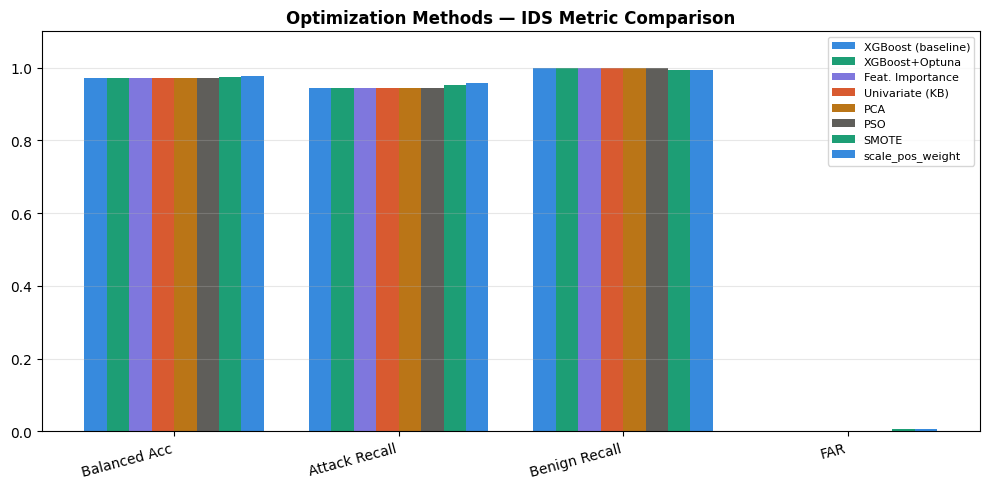

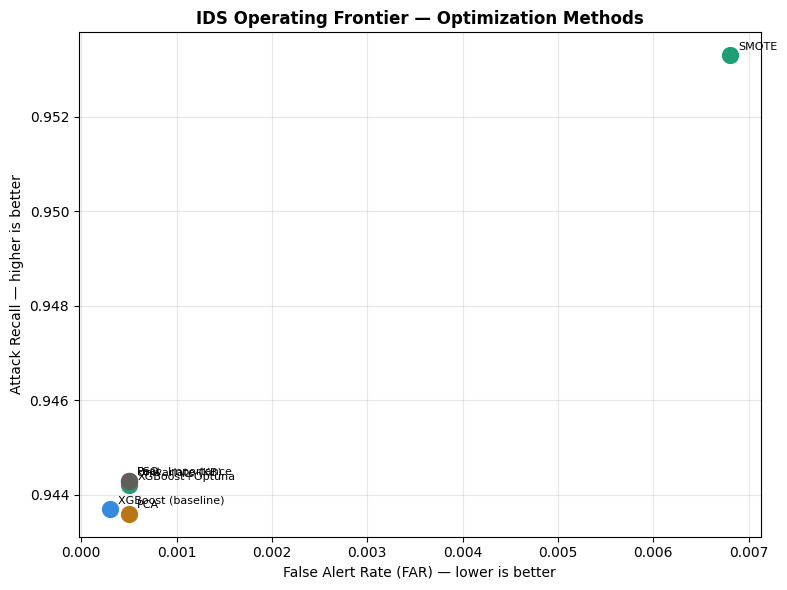

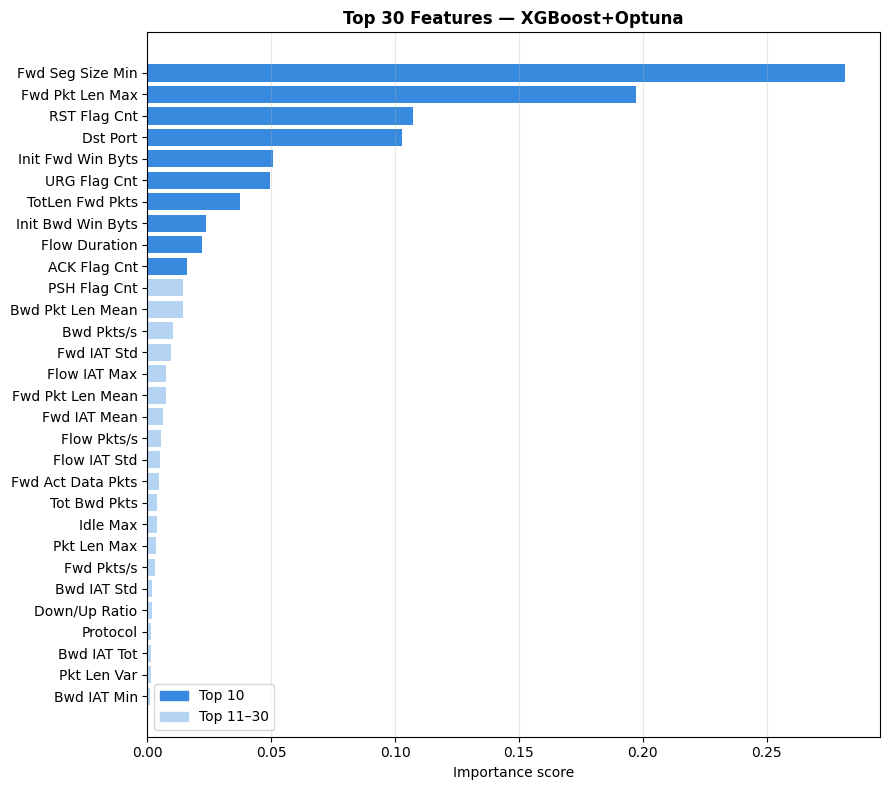

In [15]:
# Cell 13 — Optimization comparison graphs
import os
os.makedirs("outputs/graphs", exist_ok=True)

KEY = ["Balanced Acc", "Attack Recall", "Benign Recall", "FAR"]
plot_metrics_bar(
    opt_results, KEY,
    title="Optimization Methods — IDS Metric Comparison",
    save_path="outputs/graphs/03_optimization_comparison.png"
)
plot_frontier(
    opt_results,
    title="IDS Operating Frontier — Optimization Methods",
    save_path="outputs/graphs/03_frontier_optimization.png"
)

# Feature importance chart
sorted_imp   = importances[sorted_idx[:PSO_TOP_N]]
sorted_names = [feature_names[i] for i in sorted_idx[:PSO_TOP_N]]

fig, ax = plt.subplots(figsize=(9, 8))
colors_fi = ["#378ADD" if i < 10 else "#B5D4F4" for i in range(PSO_TOP_N)]
ax.barh(sorted_names[::-1], sorted_imp[::-1], color=colors_fi[::-1])
ax.set_xlabel("Importance score")
ax.set_title(f"Top {PSO_TOP_N} Features — XGBoost+Optuna", fontweight="bold")
ax.grid(True, axis="x", alpha=0.3)
legend = [
    mpatches.Patch(color="#378ADD", label="Top 10"),
    mpatches.Patch(color="#B5D4F4", label=f"Top 11–{PSO_TOP_N}")
]
ax.legend(handles=legend)
plt.tight_layout()
plt.savefig("outputs/graphs/03_feature_importance.png", dpi=150)
plt.show()

In [16]:
# Cell 14 — Save all optimization results
opt_data = {
    "optuna_m"    : optuna_m,
    "fi_m"        : fi_m,
    "uni_m"       : uni_m,
    "pca_m"       : pca_m,
    "pso_m"       : pso_m,
    "smote_m"     : smote_m,
    "spw_m"       : spw_m,
    "study"       : study,
    "best_params" : study.best_params,
    "top_features": top_features,
    "pso_features": pso_features,
    "proba_optuna": proba_optuna,
}

with open("models/ml/opt_results.pkl", "wb") as f:
    pickle.dump(opt_data, f)

print("Notebook 03 complete — proceed to 04_deep_learning.ipynb")
print(f"\nSaved artifacts:")
print("  models/ml/best_xgb.pkl")
print("  models/ml/optuna_study.pkl")
print("  models/ml/xgb_fi.pkl")
print("  models/ml/xgb_uni.pkl  +  selector_uni.pkl")
print("  models/ml/xgb_pca.pkl  +  pca.pkl  +  pca_scaler.pkl")
print("  models/ml/xgb_pso.pkl  +  pso_features.pkl")
print("  models/ml/xgb_smote.pkl")
print("  models/ml/xgb_spw.pkl")
print("  models/ml/opt_results.pkl")

Notebook 03 complete — proceed to 04_deep_learning.ipynb

Saved artifacts:
  models/ml/best_xgb.pkl
  models/ml/optuna_study.pkl
  models/ml/xgb_fi.pkl
  models/ml/xgb_uni.pkl  +  selector_uni.pkl
  models/ml/xgb_pca.pkl  +  pca.pkl  +  pca_scaler.pkl
  models/ml/xgb_pso.pkl  +  pso_features.pkl
  models/ml/xgb_smote.pkl
  models/ml/xgb_spw.pkl
  models/ml/opt_results.pkl
